# Plot Generation for ARI Figure

In [2]:
from tifffile import imread
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns
from itertools import combinations
import os 
os.makedirs('ARI_fig', exist_ok=True)
import numpy as np



In [3]:
# Set seaborn style (optional)
sns.set(style="whitegrid")
sns.set_palette(["#9b59b6", "#e74c3c"])  # purple, red

samples = ['mouse_brain','mouse_embryo','mouse_kidney','mouse_intestine','human_lung', 'human_colon']
#samples = ['human_colon']
data = {}
merged_dfs = {}
for sample in samples:
    # Paths to data files
    path = f'/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/{sample}/{sample}_run/plots/overview/'
    ari_segmentation = pd.read_csv(path+"ARI_segmentation.csv")
    data[f"{sample}_ari_df"] = ari_segmentation

In [4]:
method_map = {
    'cyto_filtered_naive_8um': 'Naive 8um',
    'cyto_filtered_stardist_proximity': 'StarDist + Proximity',
    'cyto_filtered_stardist_voronoi': 'StarDist + Mask + Voronoi',
    'nuc_filtered_stardist': 'StarDist Nuclei',
    'cyto_filtered_cellpose_proximity': 'Cellpose + Proximity',
    'cyto_filtered_cellpose_voronoi': 'Cellpose + Mask + Voronoi',
    'cyto_filtered_cellpose': 'Cellpose3 Cytoplasm',
    'nuc_filtered_cellpose': 'Cellpose Nuclei',
    'cyto_filtered_bin2cell': 'Bin2Cell Cytoplasm',
    'cyto_filtered_STP_tuned': 'STP Tuned',
    'cyto_filtered_STP_untuned': 'STP Untuned',
}

<Figure size 1000x800 with 0 Axes>

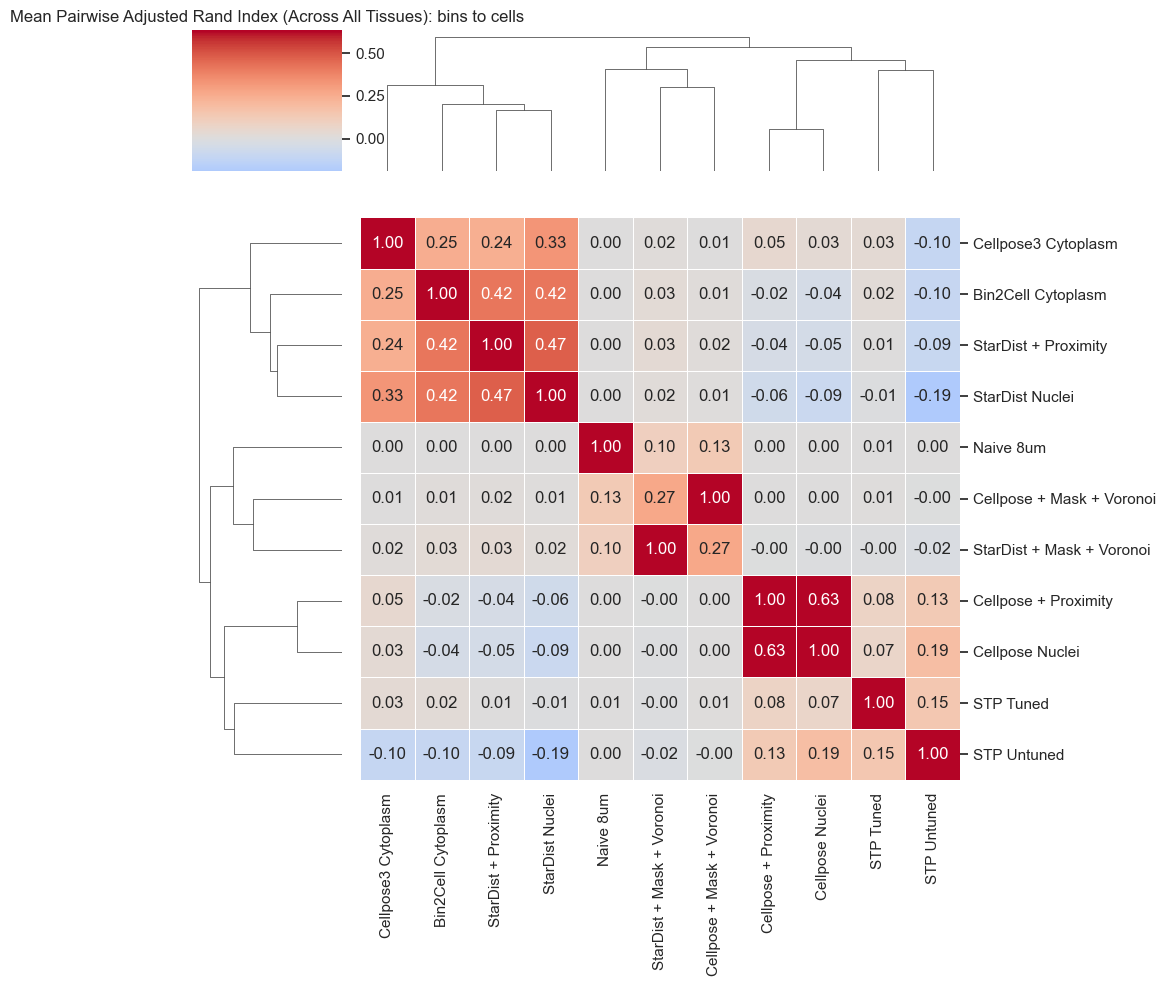

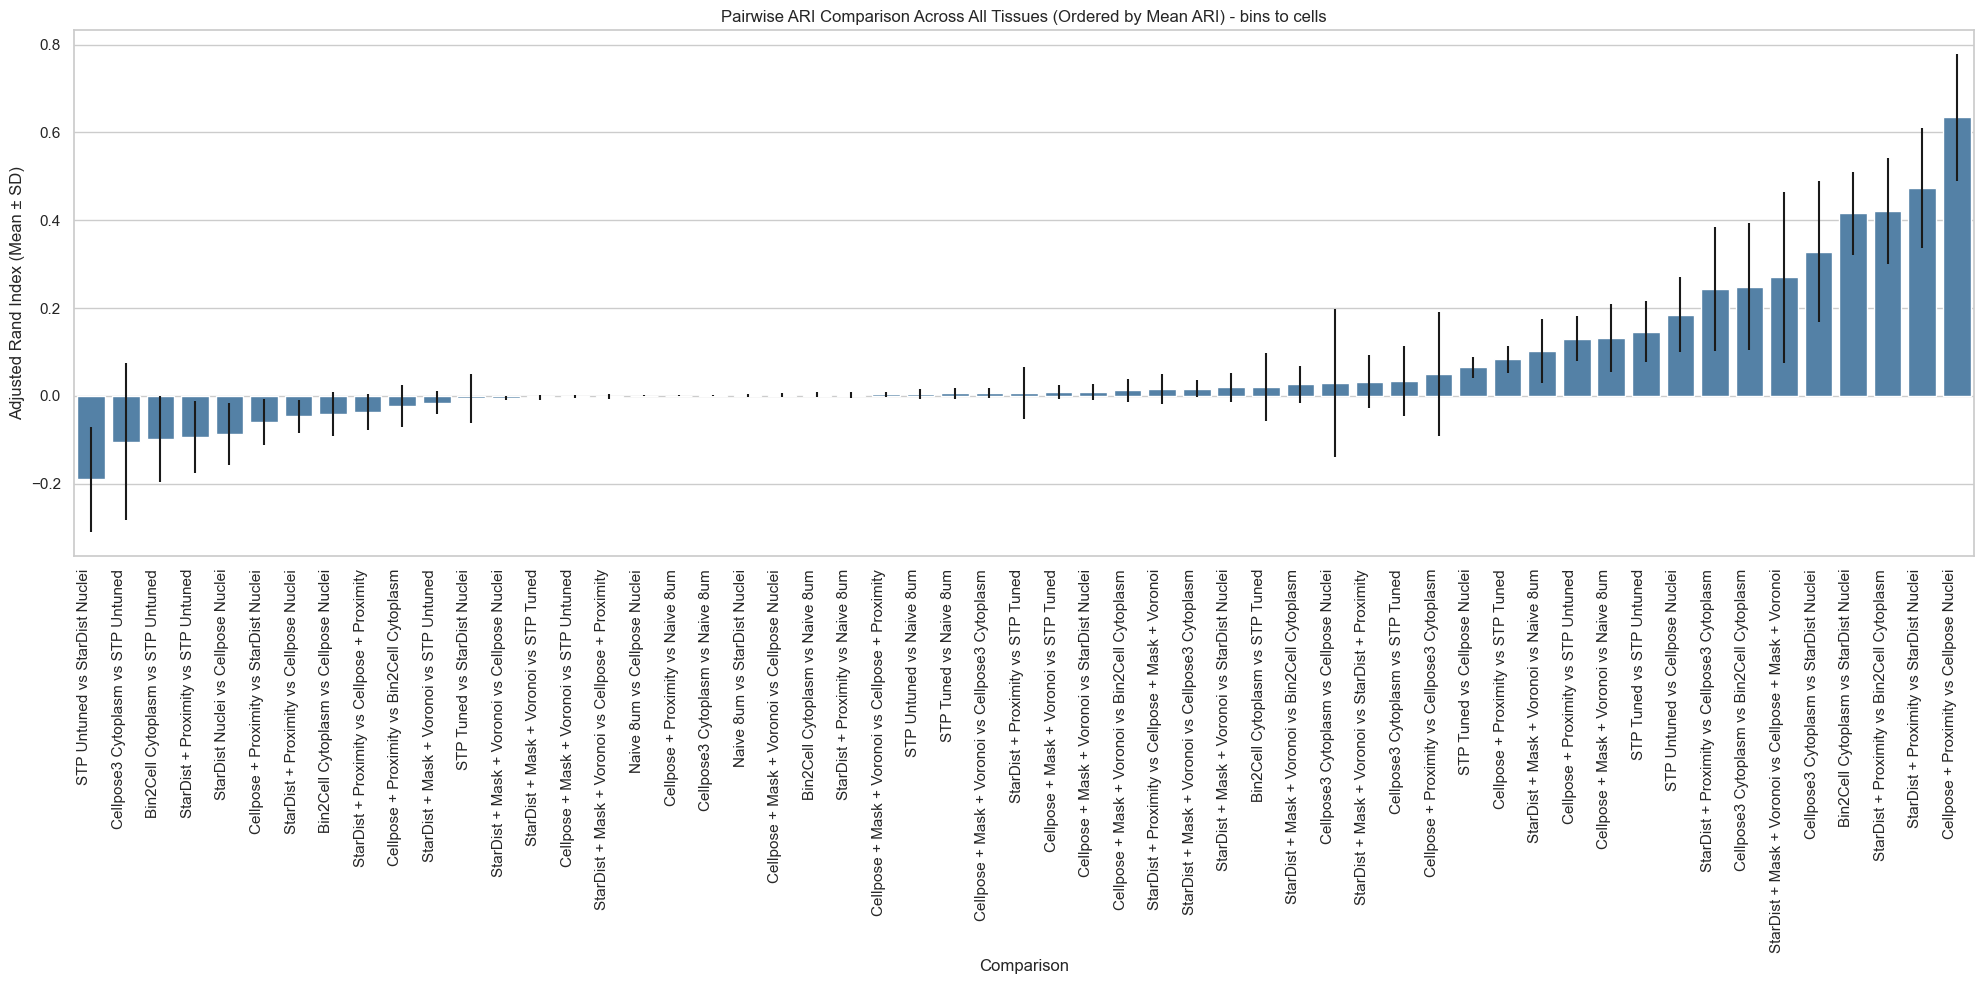

In [5]:
# Collect ARI matrices for all samples
ari_cell_matrices = []
ari_cluster_matrices = []
cellpose_cyto_info = []
for sample in samples:
    ari_df = data[f"{sample}_ari_df"]
    ari_df = ari_df[~ari_df['Method_1'].str.contains('nuc_filtered_bin2cell') & ~ari_df['Method_2'].str.contains('nuc_filtered_bin2cell')]
    methods = pd.unique(ari_df[['Method_1', 'Method_2']].values.ravel())


    # Create empty matrix
    ari_cell_matrix = pd.DataFrame(np.eye(len(methods)), index=methods, columns=methods)
    ari_cluster_matrix = pd.DataFrame(np.eye(len(methods)), index=methods, columns=methods)

    # Fill with ARI values
    for _, row in ari_df.iterrows():
        m1, m2, cell_ari, cluster_ari = row['Method_1'], row['Method_2'], row['Cell_ARI'], row['Cluster_ARI']
        if m1 == 'cyto_filtered_cellpose' or m2 == 'cyto_filtered_cellpose':
            cellpose_cyto_info.append({
                "Sample": sample,
                "Method_1": m1,
                "Method_2": m2,
                "Cell_ARI": cell_ari,
                "Cluster_ARI": cluster_ari
            })
        ari_cell_matrix.loc[m1, m2] = cell_ari
        ari_cell_matrix.loc[m2, m1] = cell_ari
        ari_cluster_matrix.loc[m1, m2] = cluster_ari
        ari_cluster_matrix.loc[m2, m1] = cluster_ari


    ari_cell_matrices.append(ari_cell_matrix)
    ari_cluster_matrices.append(ari_cluster_matrix)

# --- Compute mean and SD across all samples ---
cell_ari_mean = pd.concat(ari_cell_matrices).groupby(level=0).mean()
cell_ari_sd = pd.concat(ari_cell_matrices).groupby(level=0).std()
cluster_ari_mean = pd.concat(ari_cluster_matrices).groupby(level=0).mean()
cluster_ari_sd = pd.concat(ari_cluster_matrices).groupby(level=0).std()

# Map the row/column names
cell_ari_mean_named = cell_ari_mean.rename(index=method_map, columns=method_map)
cluster_ari_mean_named = cluster_ari_mean.rename(index=method_map, columns=method_map)
cell_ari_sd_named = cell_ari_sd.rename(index=method_map, columns=method_map)
cluster_ari_sd_named = cluster_ari_sd.rename(index=method_map, columns=method_map)


# --- Plot heatmap of mean ARIs ---
vmax = cell_ari_mean[cell_ari_mean < 1].max().max()
plt.figure(figsize=(10, 8))
sns.clustermap(
    cell_ari_mean_named,
    annot=True,
    fmt=".2f",
    row_cluster=True,
    col_cluster=True, 
    cmap="coolwarm",
    center=0,
    vmin=cell_ari_mean_named.min().min(),
    vmax=vmax,
    linewidths=0.5,
    metric="euclidean",
    method="average"
)

plt.title("Mean Pairwise Adjusted Rand Index (Across All Tissues): bins to cells")
plt.tight_layout()
plt.savefig('ARI_fig/Pairwise_ARI_avg_heatmap_bins_to_cells.pdf')
plt.show()

#vmax = cluster_ari_mean[cluster_ari_mean < 1].max().max()
#plt.figure(figsize=(10, 8))

#sns.clustermap(
#    cluster_ari_mean_named,
#    annot=True,
#    fmt=".2f",
#    row_cluster=True,
#    col_cluster=True, 
#    cmap="coolwarm",
#    center=0,
#    vmin=cell_ari_mean_named.min().min(),
#    vmax=vmax,
#    linewidths=0.5,
#    metric="euclidean",
#    method="average"
#)

#plt.title("Mean Pairwise Adjusted Rand Index (Across All Tissues): bins to clusters")
#plt.tight_layout()
#plt.show()

# --- Prepare data for bar plot ---
bar_data = []

bar_data = []
for i, j in combinations(cell_ari_mean.columns, 2):
    bar_data.append({
        "Comparison": f"{method_map[i]} vs {method_map[j]}",
        "Mean_ARI": cell_ari_mean.loc[i, j],
        "SD_ARI": cell_ari_sd.loc[i, j]
    })
bar_df = pd.DataFrame(bar_data)


# --- Bar plot of mean ± SD (ordered in increasing mean ARI) ---
bar_df = bar_df.sort_values(by="Mean_ARI", ascending=True)

plt.figure(figsize=(20, 10))
sns.barplot(
    data=bar_df,
    x="Comparison",
    y="Mean_ARI",
    yerr=bar_df["SD_ARI"],
    capsize=0.1,
    color="steelblue"
)
plt.xticks(rotation=90, ha="right")
plt.ylabel("Adjusted Rand Index (Mean ± SD)")
plt.title("Pairwise ARI Comparison Across All Tissues (Ordered by Mean ARI) - bins to cells")
plt.tight_layout()
plt.savefig('ARI_fig/Pairwise_ARI_tissue_variation_bins_to_cells.pdf')
plt.show()


In [6]:
top = bar_df.sort_values(by="SD_ARI", ascending=False).head(10)
# Split the 'Comparison' column into two separate columns
top[['Method_1', 'Method_2']] = top['Comparison'].str.split(' vs ', expand=True)

# Combine both columns into a single series and count occurrences
#method_counts = pd.concat([top['Method_1'], top['Method_2']]).value_counts()

#print(method_counts)

# make pie chart
#plt.figure(figsize=(8, 8))
#method_counts.plot.pie( startangle=140, colors=sns.color_palette("pastel"))
#plt.title("Segmentation Methods in Top 10 Most Variable ARI Comparisons")
#plt.ylabel("")  # Hide y-label
#plt.tight_layout()
#plt.show()

In [7]:
var_top = top[(top['Method_1'] == 'Cellpose3 Cytoplasm') | (top['Method_2'] == 'Cellpose3 Cytoplasm')]
methods_of_interst = set()

methods_of_interst.update(var_top['Method_1'])
methods_of_interst.update(var_top['Method_2'])
methods_of_interst.discard('Cellpose3 Cytoplasm')

In [8]:
df = pd.DataFrame(cellpose_cyto_info)
df['Method'] = df.apply(
    lambda row: row['Method_1'] if row['Method_2'] == 'Cellpose3 Cytoplasm' else row['Method_2'],
    axis=1
)
# map Method to method_map
df['Method_Named'] = df['Method'].map(method_map)
df = df[df['Method'].isin(methods_of_interst)]
dictionary = {'cyto_filtered_stardist_proximity': 'StarDist', 
              'cyto_filtered_cellpose_proximity': 'Cellpose', 
              'cyto_filtered_bin2cell': 'StarDist',
              'cyto_filtered_STP_tuned': 'Cellpose',
              'cyto_filtered_STP_untuned': 'Cellpose',
              'nuc_filtered_stardist': 'StarDist',
                'nuc_filtered_cellpose': 'Cellpose'
              }

df['Base_method'] = df['Method'].map(dictionary)

In [9]:
df = pd.DataFrame(cellpose_cyto_info)
df['Method'] = df.apply(
    lambda row: row['Method_1'] if row['Method_2'] == 'cyto_filtered_cellpose' else row['Method_2'],
    axis=1
)
df.drop(columns=['Method_1', 'Method_2'], inplace=True)
# map Method to method_map
df['Method'] = df['Method'].map(method_map)
df = df[df['Method'].isin(methods_of_interst)]

dictionary = {
    'StarDist + Proximity': 'StarDist',
    'Cellpose + Proximity': 'Cellpose',
    'Bin2Cell Cytoplasm': 'StarDist',
    'STP Tuned': 'Cellpose',
    'STP Untuned': 'Cellpose',
    'StarDist Nuclei': 'StarDist',
    'Cellpose Nuclei': 'Cellpose'
}
df['Base_method'] = df['Method'].map(dictionary)


In [10]:
tissue_dict = {
    'mouse_brain': 'Mouse Brain',
    'mouse_embryo': 'Mouse Embryo',
    'mouse_kidney': 'Mouse Kidney',
    'mouse_intestine': 'Mouse Intestine',
    'human_lung': 'Human Lung',
    'human_colon': 'Human Colon'
}

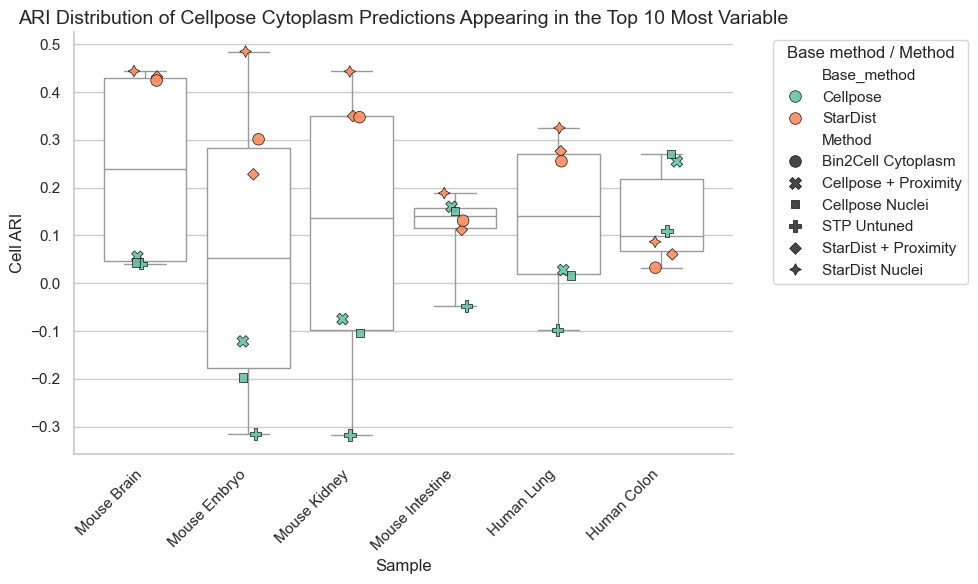

In [11]:
# Ensure categorical types (recommended)
df['Base_method'] = df['Base_method'].astype('category')
df['Method'] = df['Method'].astype('category')

df['Sample'] = df['Sample'].map(tissue_dict)

# --- Add horizontal jitter manually ---
# Convert categorical 'Sample' to numeric for jitter, then map back
sample_to_num = {cat: i for i, cat in enumerate(df['Sample'].unique())}
df['x_jittered'] = df['Sample'].map(sample_to_num) + np.random.uniform(-0.15, 0.15, size=len(df))

plt.figure(figsize=(10, 6))

# --- Boxplot for background distribution ---
sns.boxplot(
    data=df,
    x='Sample',
    y='Cell_ARI',
    color='white',
    fliersize=0,
    linewidth=1,
    whis=(0, 100),
    zorder=1
)

# --- Scatterplot with jitter ---
sns.scatterplot(
    data=df,
    x='x_jittered',        # use jittered x positions
    y='Cell_ARI',
    hue='Base_method',
    style='Method',
    palette='Set2',
    s=70,
    alpha=0.9,
    edgecolor='black',
    linewidth=0.5,
    zorder=2
)

# Replace x-ticks with original labels
plt.xticks(ticks=range(len(sample_to_num)), labels=sample_to_num.keys(), rotation=45, ha='right')

plt.title("ARI Distribution of Cellpose Cytoplasm Predictions Appearing in the Top 10 Most Variable", fontsize=14)
plt.ylabel('Cell ARI', fontsize=12)
plt.xlabel('Sample', fontsize=12)
plt.legend(title='Base method / Method', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.savefig('ARI_fig/Cellpose_cytoplasm_ARI_variability_top10_bins_to_cells.pdf', format='pdf')
plt.show()


### Spatial Visuals
Want to show case where it is more similar to cellpose and when more similar to stardist 
- Human colon (Cellpose Method)
- Mouse Embryo (StarDist Method)

In [12]:
# Human colon 
col_img = imread("/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/data/human_colon/Visium_HD_Human_Colon_Cancer_tissue_image.btf")
star_nuc_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/human_colon/human_colon_run/stardist_nuclei.gpkg')
cell_nuc_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/human_colon/human_colon_run/cellpose_nuclei.gpkg')
cell_cyto_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/human_colon/human_colon_run/cellpose_cyto.gpkg')

microns_per_pixel = 0.2738242950835738 # From human_colon/binned_outputs/square_002um/spatial/scalefactors_json.json

region_x = [55000, 55500]
region_y= [11500, 12000]

# crop image to region of interest
cropped_img = col_img[region_y[0]:region_y[1], region_x[0]:region_x[1]]

# move all gdfs to origin
# shift all geometries by negative crop offsets
star_nuc_gdf["geometry"] = star_nuc_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])
cell_nuc_gdf["geometry"] = cell_nuc_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])
cell_cyto_gdf["geometry"] = cell_cyto_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])



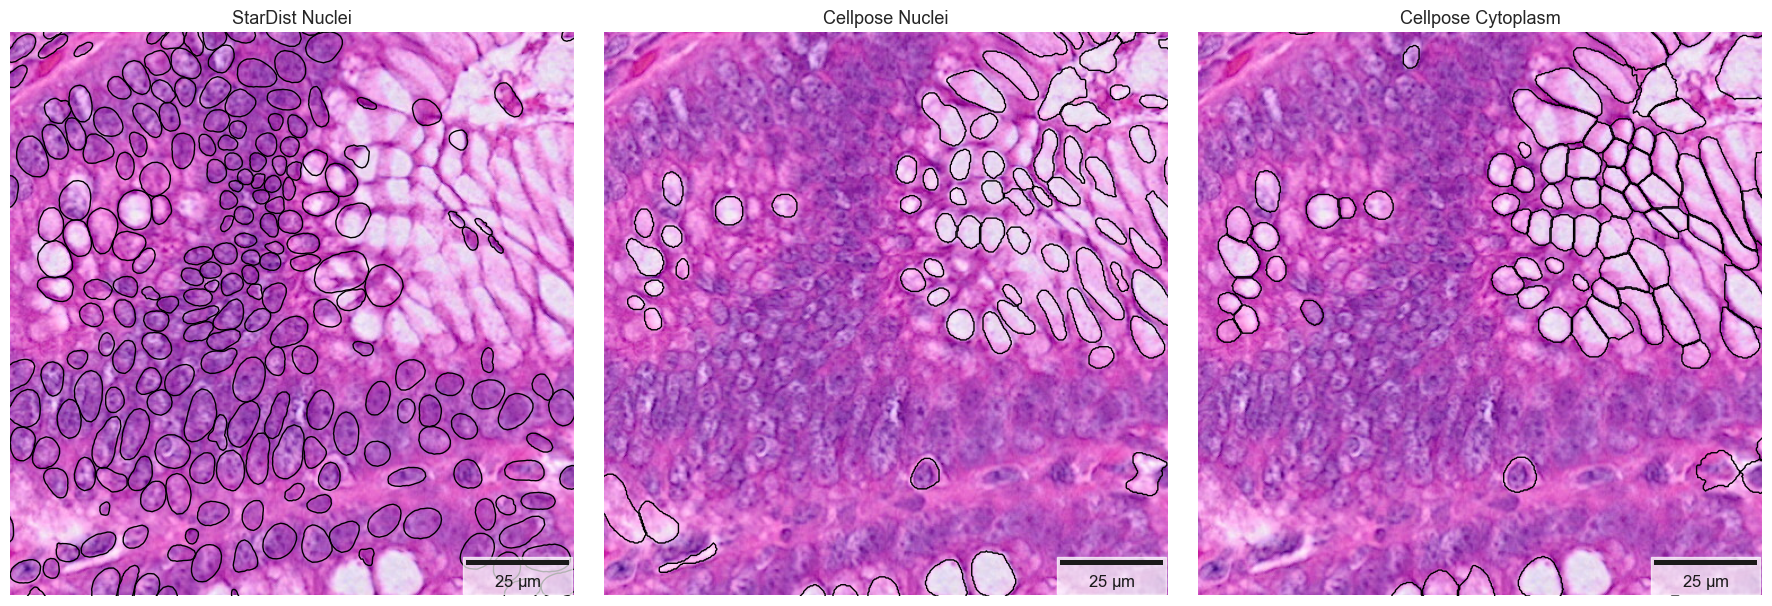

In [13]:
# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
 
titles = [
    "StarDist Nuclei",
    "Cellpose Nuclei",
    "Cellpose Cytoplasm"
]
gdfs = [star_nuc_gdf, cell_nuc_gdf, cell_cyto_gdf]
colors = ["black", "black", "black"]

# Get consistent axis limits based on cropped image dimensions
img_height, img_width = cropped_img.shape[:2]
xlim = (0, img_width)
ylim = (img_height, 0)  # flip y for image origin at top-left

for ax, gdf, title, color in zip(axes, gdfs, titles, colors):
    ax.imshow(cropped_img)
    gdf.plot(ax=ax, edgecolor=color, facecolor='none', linewidth=1)
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

    # Fix extent for consistent size across panels
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Add scale bar
    scalebar = ScaleBar(microns_per_pixel, "µm", length_fraction=0.25,
                        location="lower right", box_alpha=0.7)
    ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig('ARI_fig/human_colon_nuclei_cyto_comparison.pdf')
plt.show()


In [14]:
# Mouse Embryo 
emb_img = imread("/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/data/mouse_embryo/Visium_HD_Mouse_Embryo_tissue_image.btf")
star_nuc_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/mouse_embryo/mouse_embryo_run/stardist_nuclei.gpkg')
cell_nuc_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/mouse_embryo/mouse_embryo_run/cellpose_nuclei.gpkg')
cell_cyto_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/mouse_embryo/mouse_embryo_run/cellpose_cyto.gpkg')

microns_per_pixel = 0.2737858768391661 # From mouse_embryo/binned_outputs/square_002um/spatial/scalefactors_json.json

region_x=[14000, 14500]
region_y=[14000, 14500]


# crop image to region of interest
cropped_img = emb_img[region_y[0]:region_y[1], region_x[0]:region_x[1]]

# move all gdfs to origin
# shift all geometries by negative crop offsets
star_nuc_gdf["geometry"] = star_nuc_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])
cell_nuc_gdf["geometry"] = cell_nuc_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])
cell_cyto_gdf["geometry"] = cell_cyto_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])

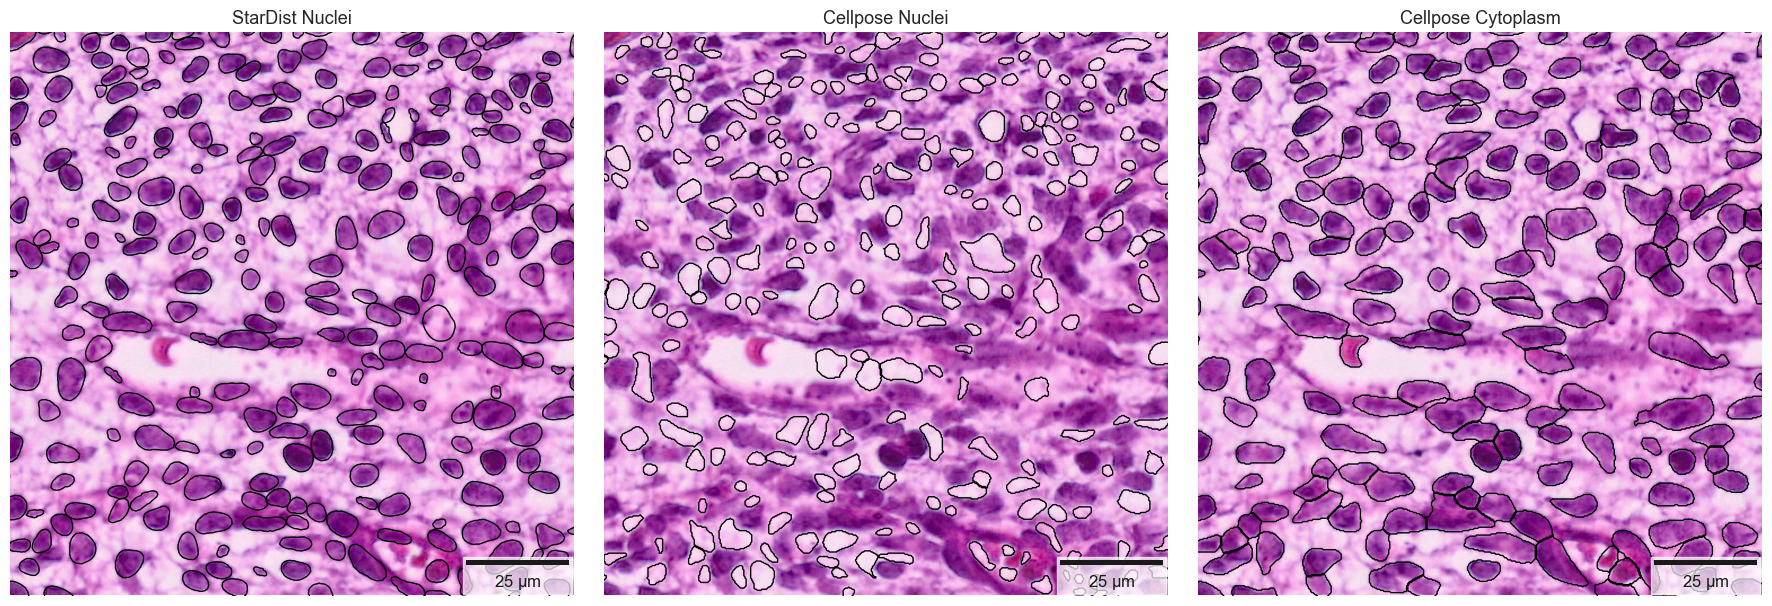

In [15]:
# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = [
    "StarDist Nuclei",
    "Cellpose Nuclei",
    "Cellpose Cytoplasm"
]
gdfs = [star_nuc_gdf, cell_nuc_gdf, cell_cyto_gdf]
colors = ["black", "black", "black"]

# Get consistent axis limits based on cropped image dimensions
img_height, img_width = cropped_img.shape[:2]
xlim = (0, img_width)
ylim = (img_height, 0)  # flip y for image origin at top-left

for ax, gdf, title, color in zip(axes, gdfs, titles, colors):
    ax.imshow(cropped_img)
    gdf.plot(ax=ax, edgecolor=color, facecolor='none', linewidth=1)
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

    # Fix extent for consistent size across panels
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Add scale bar
    scalebar = ScaleBar(microns_per_pixel, "µm", length_fraction=0.25,
                        location="lower right", box_alpha=0.7)
    ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig('ARI_fig/mouse_embryo_nuclei_cyto_comparison.pdf')
plt.show()
